# GPUs/ CUDA
> This is a notebook for the distributed systems course project. The purpose of this presentation is to give an introduction to the GPU architecture and CUDA programming and share some of the experience gained while experimenting. It is divided into four subtopics:
> - A look into the GPU architecture
> - Introduction to CUDA
> - GEMM optimizations
> - Making a local cluster

## A look into the GPU architecture

### CPU vs GPU

I think that it is important to try and revisit the CPU architecture before diving into the GPU. We all know that the CPU is the base of our computers. For that, it has a general purpose, and processing should be done sequentially, so that the order of events is respected. It has few cores, so it has a lot of cache and low latency to give the impression that things happen instantly. It specializes in doing complex logic, handling I/O and managing all other components in the machine. 

The GPU on the other hand have a more specific usage, as it is great at doing huge ammounts of calculations. It has many cores, so, even though they have lower cache and high latency, the idea here is that by paralalizing instructions one can achieve a high throughput. It isn't good at doing complex instructions. In simpler terms, if the CPU is the captain of the pc, then the GPU is an army of workers.

The complexity of the CPU is much hidden from the user, and can often be ignored. Achieving great performance while doing things in parallel needs more understanding and exposes more complexity.

### GPU architecture

There are different GPU architectures by different manufactures with different implementations. The focus here is on the general NVidia architecture, since CUDA can only run in these GPUs and has many elements that are inheretly linked. 

Here, there are three main levels:

- Thread level: This is the lowest level. Here, there are many execution units for different opperations (int and float operations, load and store from memory). Note that there are many of these blocks, so that instructions are grouped and executed together in 'Single Instruction Multiple Thread' operations. Threads are organized in blocks of 32 called 'warps', which are the basic unit of work. An instruction will perform an operation in all 32 threads of a warp at once. 

![image.png](assets/image.png)

- Streaming Multiprocessor: This next level is called a Streaming Multiprocessor or SM. It hosts some of these cores and has a shared memory, which means that threads in a same block (more on blocks later) have access to local shared variables that reside in this shared memory.

![image-2.png](assets/image2.png)

- GPU: This brings together many SMs (in this schematic of the Nvidia H100 there are 144 SMs), with a global memory (VRAM)

![image-3.png](assets/image3.png)

## Introduction to CUDA

CUDA programs usually follow a specific flow:
- CPU allocates host memory
- CPU copies data to device memory
- CPU launches kernel on the GPU
- CPU copies results back to CPU memory

Note that it is common to use different terminology for CPU/ GPU. CPU is refered as the host and the GPU as the device. Kernels are functions that are executed in GPU. 

Also note that memory used by the device is not in the usual RAM sticks on the motherboard. Instead they are in the VRAM in your GPU, which is why they need to be copied for every kernel execution.

CUDA is based of C and supports C++. It has its own compiler ```nvcc```.

Kernels are meant to look like a serial program, as it should represent what every thread allocated to this kernel should do and follow. Threads are grouped into blocks in a grid, so that each thread can be uniquely identified within a block by coordinates that are given by the CUDA API `threadIdx`, and every block is also uniquely identified by coordinates by `blockIdx`. These coordinates can be 1D, 2D or 3D, depending on the way that the user declares the block and grid dimensions. Below is an example of a kernel that performs vector addition C = A + B, n is the size of the vectors. The `__global__` prefix serves to identify that this function is a kernel:

```C
__global__ void solve(const float *A, const float *B, float *C, int n){
    int i = threadIdx.x + blockIdx.x * blockDim.x;
    if(i >= n) return;
    C[i] = A[i]+B[i];
}
```

As it was previously stated, in order to execute these kernels there is a set of things that must be done. I detailed the typical flow below:

```C
void execute_kernel(const float *A, const float *B, float *C, int n){
    // the 'd' suffix indicates that this points to a device variable
    float *Ad, *Bd, *Cd;

    // this allocs VRAM memory to our variables
    cudaMalloc((void**)Ad, n*sizeof(float));
    cudaMalloc((void**)Bd, n*sizeof(float));
    cudaMalloc((void**)Cd, n*sizeof(float));

    // we copy the input vectors to device
    cudaMemcpy(Ad, A, n*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(Bd, B, n*sizeof(float), cudaMemcpyHostToDevice);

    // now we should determine the size of the grid and block
    // gridDim determines the amount of blocks in the grid
    // blockDim determines the amount of threads in a block. This number should be a multiple of 32
    // dim3 is a 3d type that allows for indexing as vector, matrix or volume. In this case, we are indexing threads as a vector

    dim3 gridDim((n+63)/64), blockDim(64);

    // execute the kernel
    solve<<<gridDim, blockDim>>>(Ad, Bd, Cd, n);

    // copy the result vector Cd to host

    cudaMemcpy(C, Cd, n*sizeof(float), cudaMemcpyDeviceToHost);

    return;
}
```

Remember how the unit cell of work is a warp, and it consists of 32 threads? Because of this, blocks are composed by a group of warps, and that is why its size should be a multiple of 32.



## GEMM optimizations

Implementing GEneral Matrix Multiplication (GEMM) and trying to improve on it is a great way to understand CUDA and learn general optimizations. The first kernel that we will analyse is the naive kernel for GEMM:

```C
__global__ void gpu_mult(float *A, float *B, float *C, int n, int k, int m){
    int I = threadIdx.x + blockIdx.x * blockDim.x, J = threadIdx.y + blockIdx.y * blockDim.y;
    for(int i = I; i < n; i += gridDim.x * blockDim.x) {
        for(int j = J; j < m; j += gridDim.y * blockDim.y) {
            C[i*m+j] = 0;
            for(int p = 0; p < k; p++) C[i*m+j] += A[i*k+p] * B[p*m+j];
        }
    }
}
```

We use 2D indexing so that every thread is linked to one entry of the final matrix C. In this kernel we generalized so that we can launch a kernel with grid and block sizes such that they won't cover the entire matrix, and still it will make sure to calculate all positions of the matrix, though we expect to launch enough threads to cover the matrix. That way, for every position calculated, a thread will make 2*k global memory accesses, which are not coalesced.

When a thread requests a piece of data to your global memory, the physical part will end up reading a 32 entry chunk of your memory. Since this thread only requested a single entry, it will ignore all 31 other pieces of data that were read. What happens when a warp reads 32 adjacent slots is that the VRAM will read it all at once, and will return all of the data in a single request. This is coalesced memory access. What is happening in the above code is that, thread 0, which has coordinates (x, y), will request data slot A[x*k+p]. When we look at thread 1, which will have coordinates (x+1, y), it will request A[(x+1)*k+p] = A[x*k+p+k], which will not be adjacent to thread 0. Notice, however, that the request for B will be the exact same, so the global memory will broadcast this value.

If we make I to be dependant on y and J on x, the access in A will be broadcasted and the access in B will be coalesced. The following code implements this and shows a speedup of about 3x:

```C
__global__ void gpu_mem_coalescing(float *A, float *B, float *C, int n, int k, int m){
    int J = threadIdx.x + blockIdx.x * blockDim.x, I = threadIdx.y + blockIdx.y * blockDim.y;
    for(int i = I; i < n; i += gridDim.x * blockDim.x) {
        for(int j = J; j < m; j += gridDim.y * blockDim.y) {
            C[i*m+j] = 0;
            for(int p = 0; p < k; p++) C[i*m+j] += A[i*k+p] * B[p*m+j];
        }
    }
}
```

The next thing that we are looking to improve on is using shared memory. Let's think of a 16x16 block, and look at a thread. We can see that threads in the same row and column will most likely be asking the global memory same entries, which will help saturate the global memory (if we consider threads from different warps). Since we are doing some overwork to some extent by asking for a memory load from same addresses many times, we can be smart by optimizing our loads and sharing information between threads from the same block, by using shared memory! We can arrange the memory loads in a way so that each thread in a block is responsible for loading one entry from A and from B at a time. Below is our kernel that implements this idea:

```C
__global__ void gpu_2d_tiling(float *A, float *B, float *C, int n, int k, int m){
    int blockSize = blockDim.x;
    __shared__ float As[16*16], Bs[16*16];
    A += blockIdx.x * blockSize * k; B += blockIdx.y * blockSize;
    C += blockIdx.x * blockSize * m + blockIdx.y * blockSize;

    float temp = 0;
    int d = 0;

    while(d < k){
        __syncthreads();
        
        As[threadIdx.y*blockSize+threadIdx.x] = A[threadIdx.y*k + threadIdx.x];
        Bs[threadIdx.y*blockSize+threadIdx.x] = B[threadIdx.y*m + threadIdx.x];
    
        __syncthreads();

        for(int i = 0; i < blockSize; i++) temp += As[threadIdx.x * blockSize + i] * Bs[threadIdx.y + i*blockSize];
        d += blockSize;
        A += blockSize; B += blockSize * m;
    }

    C[threadIdx.x * m + threadIdx.y] = temp;
}
```

Our next point of performance gain is by better utilizing our register memory, which is even faster than shared memory. By using the same thought process than our last speedup, we realize that we still do some overwork when accessing the shared memory, saturating it. What we can do here is to give up some paralellization and let a thread calculate more than one entry of the final matrix C, so that more work will be done overall while having less accesses to the shared memory. This will let us have an increase in our performance by running the following kernel, where each thread calculates a collumn of 8 numbers:

```C
__global__ void gpu_2d_tiling_mult_per_thread(float *A, float *B, float *C, int n, int k, int m){
    __shared__ float As[64*8], Bs[64*8];
    float Ct[8];
    for(int i = 0; i < 8; i++) Ct[i] = 0;
    int ind = threadIdx.y * blockDim.x + threadIdx.x;

    A += blockIdx.x * 64 * k; B += blockIdx.y * 64;
    C += blockIdx.x * 64 * m + blockIdx.y * 64;

    int d = 0;

    while(d < k){
        __syncthreads();
        
        As[ind] = A[ind/8*k + ind%8];
        Bs[threadIdx.y*blockDim.x+threadIdx.x] = B[threadIdx.y*m + threadIdx.x];
    
        __syncthreads();

        for(int i = 0; i < 8; i++){
            float bs_val = Bs[ind%64 + i * 64];
            for(int j = 0; j < 8; j++){
                Ct[j] += As[i + j*8 + ind/64*8*8] * bs_val;
            } 
        }
        A += 8; B += 8 * m;
        d += 8;
    }

    for(int i = 0; i < 8; i++){
        C[ind%64 + ind/64*m*8 + i*m] = Ct[i];
    }
}
```

The next kernel is a direct improvement on the last one, where instead of every thread calculating a row of 8 numbers, now every thread will calculate an 8x8 square, with a total of 64 entries by making only 16 memory accesses:

```C
__global__ void gpu_2d_blocktiling(float *A, float *B, float *C, int n, int k, int m){
    
    // Dimensions of a single thread block
    const int TN = 8, TM = 8;
    // Dimensions of output tile computed by whole block
    const int BN = 128, BM = 64;
    int id = threadIdx.x + threadIdx.y*blockDim.x;
    const int BK = 32;


    __shared__ float As[BN*BK], Bs[BK*BM];
    float Cr[TN*TM] = {0};
    float Ar[TN] = {0}, Br[TM] = {0};

    A += BN*blockIdx.x*k, B += BM*blockIdx.y;
    C += BN*blockIdx.x*m + BM*blockIdx.y;

    int rowA = id/BK, colA = id%BK;
    int rowB = id/64, colB = id%64;

    for(int d = 0; d < k; d += BK){
        __syncthreads();

        for(int j = 0; j*128 < BN*BK; j++){
            As[j*128 + rowA * BK + colA] = A[j*4*k + rowA * k + colA];
        }

        for(int j = 0; j*128 < BM*BK; j++){
            Bs[j*128 + rowB * BM + colB] = B[j*2*m + rowB * m + colB];
        }

        __syncthreads();

        for(int cDot = id&31, cnt = 0; cnt < BK; cnt++, cDot = (cDot == 31) ? 0 : cDot+1 ){
            for(int i = 0; i < TN; i++) Ar[i] = As[(threadIdx.x*TN+i)*BK + cDot];
            for(int i = 0, idx = id&7; i < TM; i++, idx = (idx == 7) ? 0 : idx+1) Br[idx] = Bs[(threadIdx.y*TM+idx) + cDot*BM];

            for(int i = 0; i < TN; i++){
                for(int j = 0; j < TM; j++){
                    Cr[i*8+j] += Ar[i]*Br[j];
                }
            }
        }

        A += BK; B += BK*m;
    }

    for(int i = 0; i < 8; i++){
        for(int j = 0; j < 8; j++){
            C[(threadIdx.x*8+i)*m + threadIdx.y*8+j] = Cr[i*8+j];
        }
    }

    return;
}
```

Notice how the indices in the following lines are a workaround that I did while trying to minimize one of the next big points of improvement, which is bank conflicts in shared memory (which I will not go into detail here):
```C
for(int cDot = id&31, cnt = 0; cnt < BK; cnt++, cDot = (cDot == 31) ? 0 : cDot+1 )
    for(int i = 0, idx = id&7; i < TM; i++, idx = (idx == 7) ? 0 : idx+1) Br[idx] = Bs[(threadIdx.y*TM+idx) + cDot*BM];
```

Another big point of improvement is vectorized memory accesses, which enable our kernels to get even more entries from memory load at once. 

Now we can compare in the following graph the performance difference between different implementations across different architectures (CPU and GPU), for different matrix sizes.

In [36]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import io

compile_cmd = ["nvcc", "-O3", "-arch=sm_90", "-lcublas", "generalmatrixmultiplication.cu", "-o", "gemm_runner"]
subprocess.run(compile_cmd, check=True)

sizes = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]
csv_data = "n,k,m,CpuNaive,CpuGemini,GpuNaive2D,GpuNaive1D,GpuMemoryCoalescing,GpuSharedMemory,Gpu1DBlockTiling,Gpu2DBlockTiling,GpuCUBLAS\n"

numpy_times = []

print("Running benchmarks...")
for size in sizes:
    print(f"Benchmarking size: {size}x{size}x{size}")
    
    result = subprocess.run(
        ["./gemm_runner", "1", str(size), str(size), str(size)], 
        capture_output=True, 
        text=True
    )

    if result.returncode != 0:
        print(f"Error at {size}:")
        print(result.stderr)
        print("Aborting benchmark")
        break
    
    csv_data += result.stdout

    if(size <= 4096):
        x1 = np.random.rand(size, size).astype(np.float32)
        x2 = np.random.rand(size, size).astype(np.float32)
        
        # Warmup runs
        for _ in range(3):
            _ = np.matmul(x1, x2)
            
        # Timed runs (scale down the iterations for massive matrices so you don't wait forever)
        run_cnt = 20
        
        times = []
        for _ in range(run_cnt):
            t_start = time.time()
            _ = np.matmul(x1, x2)
            t_end = time.time()
            times.append(t_end - t_start)
            
        numpy_times.append(np.mean(times))
    else:
        numpy_times.append(-1.0)

print("Benchmarking complete!")

Running benchmarks...
Benchmarking size: 128x128x128
Benchmarking size: 256x256x256
Benchmarking size: 512x512x512
Benchmarking size: 1024x1024x1024
Benchmarking size: 2048x2048x2048
Benchmarking size: 4096x4096x4096
Benchmarking size: 8192x8192x8192
Benchmarking size: 16384x16384x16384
Benchmarking complete!


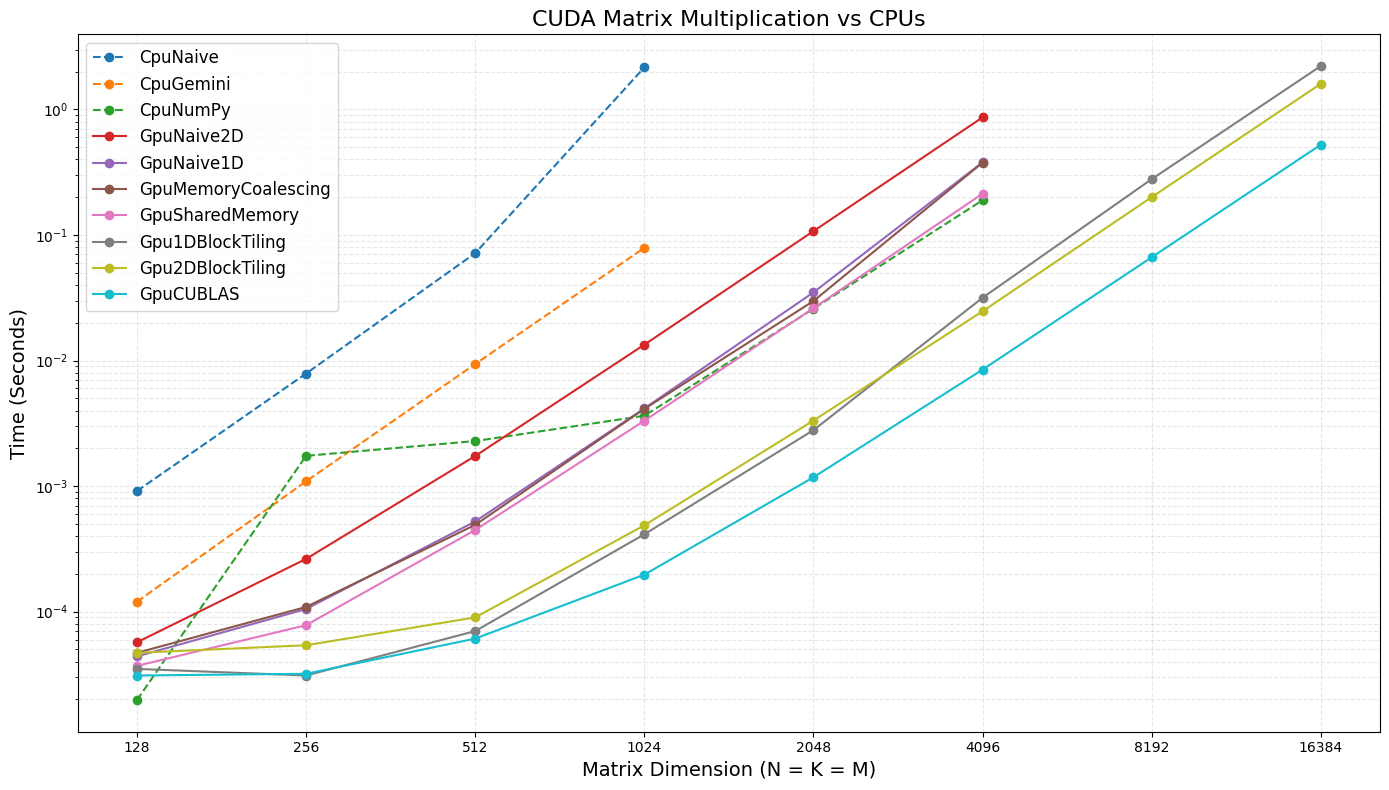

In [34]:
df = pd.read_csv(io.StringIO(csv_data))

df['CpuNumPy'] = numpy_times

#Replace C++ -1.0 with NaN so Matplotlib breaks the line
df.replace(-1.0, np.nan, inplace=True)

plt.figure(figsize=(14, 8))

# Define all columns we want to plot
plot_columns = [
    'CpuNaive', 'CpuGemini', 'CpuNumPy', 
    'GpuNaive2D', 'GpuNaive1D', 'GpuMemoryCoalescing', 'GpuSharedMemory', 'Gpu1DBlockTiling', 'Gpu2DBlockTiling', 'GpuCUBLAS'
]

# Plot each column
for col in plot_columns:
    # Filter out the NaN values for this specific line
    valid_data = df[['n', col]].dropna()
    
    # Make CPU lines dashed and GPU lines solid
    linestyle = '--' if 'Cpu' in col else '-'
    
    # Thicken the lines for the two heavyweights
    linewidth = 1.5
    
    plt.plot(
        valid_data['n'], 
        valid_data[col], 
        marker='o', 
        linestyle=linestyle, 
        linewidth=linewidth, 
        label=col
    )

plt.title('CUDA Matrix Multiplication vs CPUs', fontsize=16)
plt.xlabel('Matrix Dimension (N = K = M)', fontsize=14)
plt.ylabel('Time (Seconds)', fontsize=14)

# Keep the log scales!
plt.yscale('log') 
plt.xscale('log', base=2)
plt.xticks(sizes, labels=[str(s) for s in sizes])

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

plt.show()

### Why is Gpu2DBlockTiling worse than GPU1DBlockTiling for small matrices?

We need to understand that more paralelization in the GPU helps to hide latency of memory operations. While a warp is waiting for a load in memory to complete, the warp scheduler can switch to another warp that has completed a load, let it do some work, and when it needs to make load or store in memory, it goes back to the background, while the first warp comes back to do work after receiving his load. Note that, since we have each thread doing more work, then we have less threads executing our 2DBlockTiling. We simply don't have enough threads to hide latency! Since we gave up on some parallelism, our GPU will stall while it waits for those loads to finish, hence why it is less performatic.

## (An attempt at) Making a local cluster

To wrap this project up, I thought that it would have been a good idea to try and mix it more with distributed systems, so the point was to try and solve GEMM with a cluster of GPUs that I could try and rent in cloud. My attempt at this was by trying google's cloud solution, but it was not possible to use a cluster of GPUs without getting a special permission, which I was probably denied of (tried emailing them, no answer). There didn't seem to have any other feasible ways of having access to more than one GPU that wasn't really expensive, so I realized that I had a GTX 1050 TI in my old pc. The conclusion was that I would try to connect my current pc (which has a RTX 5060 TI) with my old pc via lan in my house and they would work together to solve a GEMM problem. Notably the GTX wasn't as good as my RTX, so I expected that I would have to give it less work.

What happened was that my programming setup wasn't specially ideal for this. I have windows in my pc, but for programming I use WSL (this is true for both my pcs), which made things kinda difficult because now I had to get both WSLs to talk without windows somehow getting in the way (which it annoyingly did). My solution was to use tailscale to connect them, but it would always connect them by using a middleman in São Paulo, which meant having a 40ms of latency and a ridiculously slow throughput of about 400KBPS. In the end, windows made it very difficult to expose wsl because of an internal NAT system, so I gave up and accepted this reality.

What I did was to generate the matrix by using a pre-coded integer seed so that I didn't have to send the input by the internet (both machines can generate the same matrix using the seed), and have the GTX calculate a small square submatrix, but even then the internet was slow enough to not let me get a decent result:

```
n = 8192, m = 8192, k = 8192
n = 8192, m = 8192, k = 65536
[Rank 1 - GTX 1050 Ti] Checkpoint at 0.827612 seconds.
[Rank 1 - GTX 1050 Ti] GPU time: 0.114238 seconds
[Rank 1 - GTX 1050 Ti] Ready at 4.88579 seconds.
[Rank 0 - RTX 5060 Ti] GPU time: 1.53888 seconds
[Distributed] Total time: 4.84314 seconds
[Rank 0 - RTX 5060 Ti only] GPU time: 1.60399 seconds
[Single] Total time: 4.02005 seconds
```

## References

- https://thechipletter.substack.com/p/demystifying-gpu-compute-architectures
- https://www.youtube.com/watch?v=86FAWCzIe_4&t
- https://github.com/Infatoshi/cuda-course/tree/master
- Programming Massively Parallel Processors
- https://siboehm.com/articles/22/CUDA-MMM
- https://docs.nvidia.com/cuda/
- https://developer.nvidia.com/blog/tag/cuda/